<center><h1>Yahoo Movies</h1></center>

In [1]:
from src import *
import src
import numpy as np
from importlib import reload
import pandas as pd
reload(src)
import matplotlib.pyplot as plt
from math import sqrt

import warnings
warnings.filterwarnings('ignore')

In [30]:
df = pd.read_csv('data/processed/yahoo_movies/yahoo_movies_filtered.csv')

In [31]:
df.to_csv('data/processed/yahoo_movies/yahoo_movies_filtered_noH.csv', index=False, header=False)

In [32]:
g = pd.read_csv('data/processed/yahoo_movies/yahoo_movies_genres_filtered.csv')

In [33]:
g.to_csv('data/processed/yahoo_movies/yahoo_movies_genres_filtered_noH.csv', index=False, header=False)

In [2]:
userColumn='userId'
itemColumn='movieId'
ratingColumn='rating'

In [3]:
loader = DataLoader(file_path='data/processed/yahoo_movies/yahoo_movies_filtered_noH.csv',
                    separator=',',
                    header=['userId', 'movieId', 'rating'],
                    genre_data_path='data/processed/yahoo_movies/yahoo_movies_genres_filtered_noH.csv',
                    genre_data_separator=',',
                    genre_data_header=['itemID', 'genres'],
                    genre_item_column='itemID',
                    genre_genre_column='genres',
                    genre_genre_separator='|',
                    genre_data_encoding='ISO-8859-1'
                    )

24/09/08 18:14:04 WARN Utils: Your hostname, david-Nitro resolves to a loopback address: 127.0.1.1; using 192.168.15.14 instead (on interface wlp9s0)
24/09/08 18:14:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/09/08 18:14:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/09/08 18:14:05 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [4]:
df = loader.load_data()
df_pandas = loader.convert_to_pandas(df)
genres_map = loader.get_genre_map()
# (train, test) = loader.train_test_separator(df)

In [5]:
df_pandas

,userId,movieId,rating
0,5,1808405757,4
1,6,1800247298,5
2,6,1805540029,5
3,6,1804090611,5
4,6,1800019304,5
...,...,...,...
161191,7642,1808409330,4
161192,7642,1808405417,5
161193,7642,1807839027,4
161194,7642,1808405428,5


In [6]:
f = df_pandas['userId'].value_counts()

In [7]:
f_mantain = f[f >= 150].index.to_list()

In [8]:
df = df_pandas[df_pandas['userId'].isin(f_mantain)]

In [9]:
df

,userId,movieId,rating
66,76,1800198688,4
67,76,1808403540,4
68,76,1800174047,4
69,76,1800111258,5
70,76,1800027621,4
...,...,...,...
159800,7553,1808406448,5
159801,7553,1800126187,5
159802,7553,1800367822,5
159803,7553,1808404477,5


24/09/08 18:14:20 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


## ALS

In [10]:
kfold = KFOLD(df, 'FC', userColumn, itemColumn, ratingColumn, genres_map)

24/09/08 18:14:20 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [11]:
results = kfold.run_cross_validation()

1) Running FC
******************************
Lambda = 0.0
Reseting metrics lists
********************
FAIRNESS MEASURE: kullback-leibler
=====1º Fold=====
Train/test spliting
Instantiating ALS...


24/09/08 18:14:21 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
24/09/08 18:14:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.5028716338588609
CALCULATING MACE
MACE = 0.04133385588320909
CALCULATING MAP
MAP = 0.049910714285714294
CALCULATING MRR
MRR = 0.055208333333333345
=====2º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.5192405805960945
CALCULATING MACE
MACE = 0.04258050572766511
CALCULATING MAP
MAP = 0.031006944444444445
CALCULATING MRR
MRR = 0.03170138888888889
=====3º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.5767755489241572
CALCULATING MACE
MACE = 0.045643552458538954
CALCULATING MAP
MAP = 0.02815972222222222
CALCULATING MRR
MRR = 0.02815972222222222
=====4º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.5050713137308042
CALCULATING MACE
MACE = 0.042753575

Calibrating...
CALCULATING MRMC
MRMC = 0.09418039703542305
CALCULATING MACE
MACE = 0.023705016256891823
CALCULATING MAP
MAP = 0.12678571428571422
CALCULATING MRR
MRR = 0.12682043650793645
=====2º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.09963121074046863
CALCULATING MACE
MACE = 0.025213490815139634
CALCULATING MAP
MAP = 0.19572916666666665
CALCULATING MRR
MRR = 0.20534722222222218
=====3º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.10253163990826664
CALCULATING MACE
MACE = 0.025809449077482255
CALCULATING MAP
MAP = 0.08798115079365079
CALCULATING MRR
MRR = 0.09475198412698413
=====4º Fold=====
Train/test spliting
Instantiating ALS...
Getting n = 100 predictions for each user
Calibrating...
CALCULATING MRMC
MRMC = 0.10170180227066179
CALCULATING MACE
MACE = 0.025543731346823927
CALCULATING MAP
MAP = 0.13258

In [13]:
results

,Lambda,FairnessMeasure,Statistic,MACE,MRMC,MAP,MRR
0,0.0,kullback-leibler,mean,0.041591,0.496326,0.030502,0.031700
1,0.0,kullback-leibler,stdev,0.001646,0.032554,0.006223,0.007079
0,0.0,hellinger,mean,0.041591,0.866138,0.030502,0.031700
1,0.0,hellinger,stdev,0.001646,0.028447,0.006223,0.007079
0,0.0,pearson,mean,0.041591,0.514676,0.030502,0.031700
...,...,...,...,...,...,...,...
1,1.0,kullback-leibler,stdev,0.000187,0.001953,0.013710,0.014263
0,1.0,hellinger,mean,0.018147,0.424477,0.146676,0.151447
1,1.0,hellinger,stdev,0.000126,0.002594,0.015223,0.017004
0,1.0,pearson,mean,0.022859,0.099821,0.140021,0.145520


In [16]:
results.to_csv('results/yahoo_movies/results_yahoo_movies3.csv', index=False)

In [2]:
# results = pd.read_csv('results/yahoo_movies/results_yahoo_movies2.csv')

In [3]:
#results.to_csv('results/yahoo_movies/results_yahoo_movies.csv', index=False)

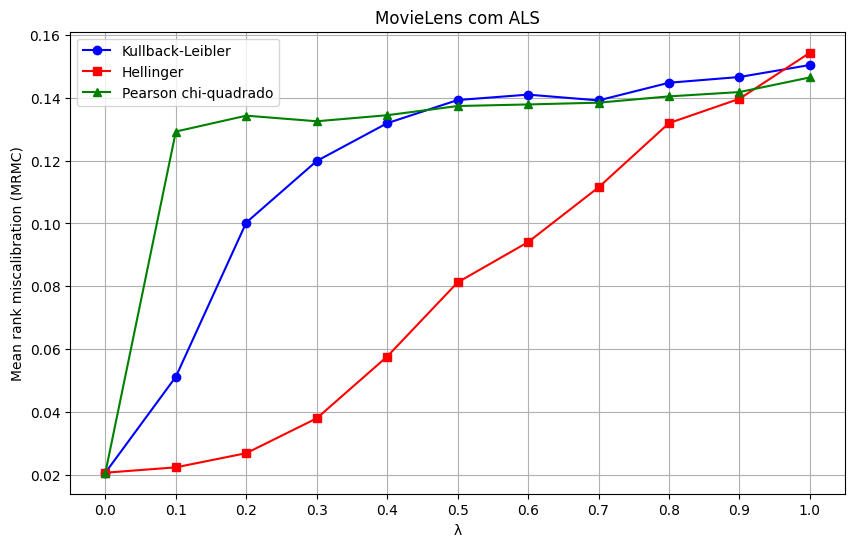

In [4]:
tradeoff_weights = results['Lambda'].drop_duplicates().to_list()
mrmc_kl = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'mean')]['MAP'].to_list()
mrmc_he = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'mean')]['MAP'].to_list()
mrmc_pe = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'mean')]['MAP'].to_list()

# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(tradeoff_weights, mrmc_kl, marker='o', linestyle='-', color='b', label='Kullback-Leibler')
plt.plot(tradeoff_weights, mrmc_he, marker='s', linestyle='-', color='r', label='Hellinger')
plt.plot(tradeoff_weights, mrmc_pe, marker='^', linestyle='-', color='g', label='Pearson chi-quadrado')

plt.xlabel('λ')
plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.ylabel('Mean rank miscalibration (MRMC)')
plt.title('MovieLens com ALS')
plt.legend()
plt.grid(True)
plt.show()


#### CRIANDO GRÁFICOS

In [17]:
def show_graphic(dataset_name, metric, title):
    short_metric = metric[metric.find('(')+1: metric.find(')')]
    tradeoff_weights = results['Lambda'].drop_duplicates().to_list()
    mrmc_kl = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'mean')][short_metric].to_list()
    mrmc_he = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'mean')][short_metric].to_list()
    mrmc_pe = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'mean')][short_metric].to_list()

    mrmc_he_err = results[(results['FairnessMeasure'] == 'hellinger') & (results['Statistic'] == 'stdev')][short_metric].to_list()
    mrmc_he_err = [std/sqrt(5) for std in mrmc_he_err]
    mrmc_kl_err = results[(results['FairnessMeasure'] == 'kullback-leibler') & (results['Statistic'] == 'stdev')][short_metric].to_list()
    mrmc_kl_err = [std/sqrt(5) for std in mrmc_kl_err]
    mrmc_pe_err = results[(results['FairnessMeasure'] == 'pearson') & (results['Statistic'] == 'stdev')][short_metric].to_list()
    mrmc_pe_err = [std/sqrt(5) for std in mrmc_pe_err]
    
    # Plotando o gráfico com barras de erro
    plt.figure(figsize=(10, 6))
    plt.errorbar(tradeoff_weights, mrmc_kl, yerr=mrmc_kl_err, marker='o', linestyle='-', color='b', label='Kullback-Leibler', capsize=5) 
    plt.errorbar(tradeoff_weights, mrmc_he, yerr=mrmc_he_err, marker='s', linestyle='-', color='r', label='Hellinger', capsize=5) 
    plt.errorbar(tradeoff_weights, mrmc_pe, yerr=mrmc_pe_err, marker='^', linestyle='-', color='g', label='Pearson chi-quadrado', capsize=5)
    
    # Configurando os rótulos e título
    plt.xlabel(r'$\lambda$')
    plt.ylabel(metric)
    plt.title(title)
    
    # Definindo os valores do eixo x para incrementar de 0.1 em 0.1
    plt.xticks(np.arange(0.0, 1.1, 0.1))
    
    plt.legend()
    plt.grid(True)
    #plt.savefig(f'results/{dataset_name}/graphs/{dataset_name}_{metric}.pgf'.replace(' ', '_'))
    plt.savefig(f'results/{dataset_name}/graphs/{dataset_name}_{metric}.pdf'.replace(' ', '_'), bbox_inches='tight')
    plt.show()
    

==========Mean Average Calibration Error (MACE)==========


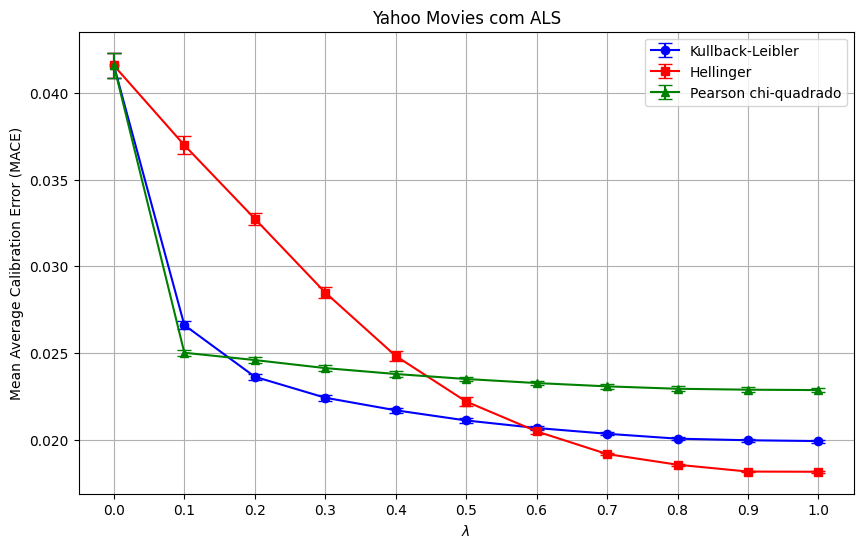

==========Mean Rank Miscalibration (MRMC)==========


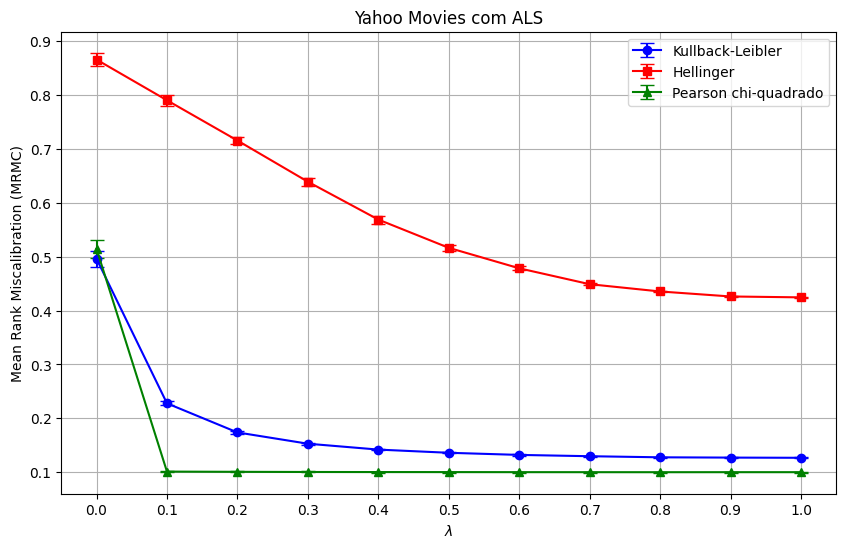

==========Mean Average Precision (MAP)==========


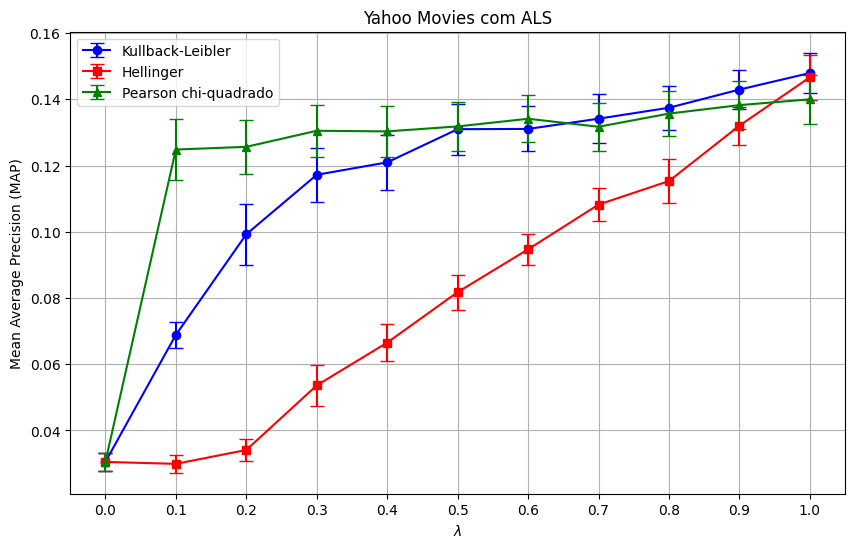

==========Mean Reciprocal Rank (MRR)==========


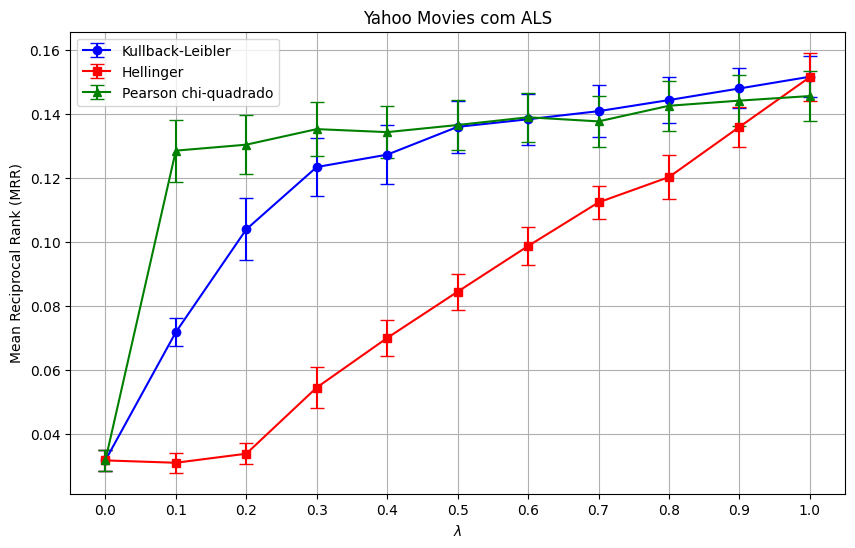

In [18]:
for metric in ['Mean Average Calibration Error (MACE)', 'Mean Rank Miscalibration (MRMC)', 'Mean Average Precision (MAP)', 'Mean Reciprocal Rank (MRR)']:
    print('=' * 10 + metric + '=' * 10)
    show_graphic('yahoo_movies', metric, 'Yahoo Movies com ALS')



In [ ]:
predictions_user_map

In [ ]:
distributions = Distributions(train.toPandas(), userColumn, itemColumn, genres_map)

In [ ]:
distributions.show_userProfileDist_userRecDist(predictions_user_map, 305)


# FBC-kNN

In [ ]:
df_genres = loader.genre_data

In [ ]:
df_genres

In [ ]:
df_expanded = df_genres['genres'].str.get_dummies(sep='|')

In [ ]:
df_final = pd.concat([df_genres[['item']], df_expanded], axis=1)

In [ ]:
df_final.index = df_final['item']

In [ ]:
df_mv_genres = df_final.drop(columns = ['item'])

In [ ]:
df_mv_genres

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
cosine_sim = cosine_similarity(df_mv_genres)

In [ ]:
df_cosine_sim = pd.DataFrame(cosine_sim, index = df_mv_genres.index, columns = df_mv_genres.index)

In [ ]:
df_cosine_sim

In [ ]:
similar_itens = list(df_cosine_sim.loc[1].sort_values(ascending=False).keys())[:102]
similar_itens.remove(1)
#rated_by_u = set(df_pandas[(df_pandas[userColumn] == 1) & (df_pandas[ratingColumn] > 0)][itemColumn].to_list())
#intersect = list(similar_itens.intersection(rated_by_u))[:101]


In [ ]:
def get_recommendatinon(movieId, userId, df_sim, df_ratings, k):
    similar_itens = list(df_sim.loc[movieId].sort_values(ascending=False).keys())[:k+2]
    similar_itens.remove(movieId)
    return similar_itens()


In [ ]:
#def get_recommendatinon(movieId, userId, df_sim, df_ratings, k):
#    similar_itens = set(df_sim.loc[movieId].sort_values(ascending=False).keys())
#    rated_by_u = set(df_ratings[(df_ratings[userColumn] == userId) & (df_ratings[ratingColumn] > 0)][itemColumn].to_list())
#    intersect = list(similar_itens.intersect(rated_by_u))[:k+1]
